In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %pip install sncosmo
# %pip install sfdmap2
# %pip install lightcurvelynx
# %pip install nested-pandas --upgrade
# %pip install pandas --upgrade
# %pip install lsdb --upgrade

In [3]:
import matplotlib.pyplot as plt
import lsdb
import numpy as np
from lightcurvelynx.astro_utils.mag_flux import flux2mag
from astropy.cosmology import Planck18
from astropy.coordinates import Distance
import astropy.units as u
from joblib import Parallel, delayed
import pandas as pd
from nested_pandas import read_parquet
import sncosmo
import nested_pandas as npd
from utils import nightly_coadd

from dask.distributed import Client

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
client = Client(n_workers=40, memory_limit="10 GiB", threads_per_worker=1)
display(client)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 32815 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:32815/status,
Dashboard: http://127.0.0.1:32815/status,Workers: 40
Total threads: 40,Total memory: 400.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37649,Workers: 0
Dashboard: http://127.0.0.1:32815/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43253,Total threads: 1
Dashboard: http://127.0.0.1:45827/status,Memory: 10.00 GiB
Nanny: tcp://127.0.0.1:33659,


2026-07-25 02:48:06,396 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='localhost:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.pro

In [5]:
import os
os.environ["SFD_DIR"] = "/astro/users/midai/sfdmap2/sfddata-master"

In [ ]:
DDF = False
refit_salt = True
SKIP_BAZIN = True
RETRY_BAND_BASELINES = True  # retry rejected SALT fits with signed band reference levels

In [7]:
from pathlib import Path
outdir = Path('outputs/')

In [8]:
columns = ["max_reliability","max_snr","ndet","nbands","n_g","n_r","n_i","n_z","dt",
           "median_flux_diff_ratio","median_flux_diff_ratio_abs","_dist_arcsec"]
bins_map = {"median_flux_diff_ratio": np.linspace(0,5,20),
        "median_flux_diff_ratio_abs": np.linspace(0,1,20)}
if DDF:
    sncandid_filename = "sncandid_w_bazin_ddf"
else:
    sncandid_filename = "sncandid_w_bazin"
sncat_meta = lsdb.open_catalog(outdir / sncandid_filename,columns=columns)

In [9]:
len(sncat_meta)

56647

In [10]:
snmeta = sncat_meta.head(200)

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 65.23it/s]


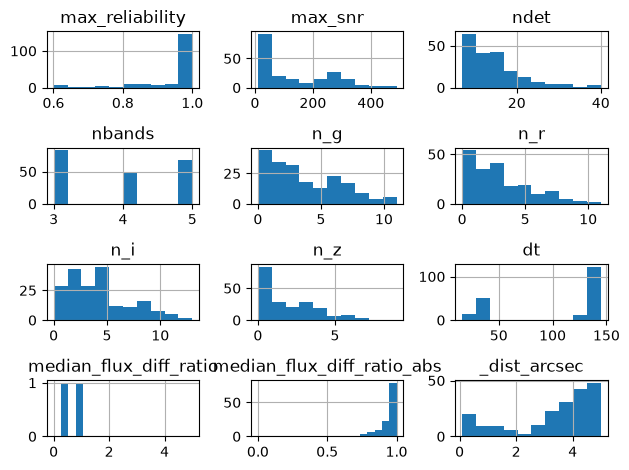

In [11]:
for i,col in enumerate(columns):
    plt.subplot(4,3,i+1)
    if col in bins_map.keys():
        bins = bins_map[col]
    else:
        bins = None
    snmeta[col].hist(bins=bins)
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
bazin_cols = [f"bazin_fit_reduced_chi2_{b}" for b in "griz"]
sncat_bazin = lsdb.open_catalog(outdir / sncandid_filename,columns=bazin_cols)

In [13]:
snbazin = sncat_bazin.head(200)

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 39.76it/s]


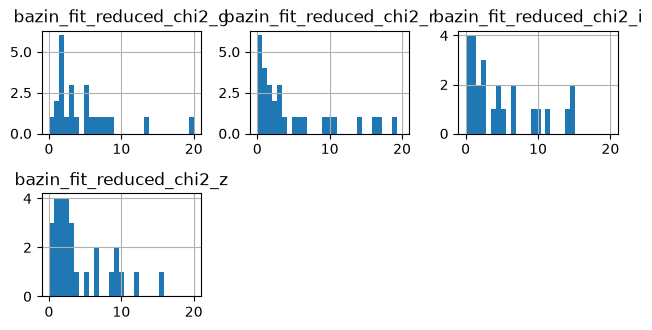

In [14]:
for i,col in enumerate(bazin_cols):
    plt.subplot(3,3,i+1)
    snbazin[col].hist(bins=np.linspace(0,20,30))
    plt.title(col)
plt.tight_layout()
plt.show()

In [15]:
sncat = lsdb.open_catalog(outdir / sncandid_filename)

In [16]:
def filter_bazin(df):
    df = df.query("((bazin_fit_reduced_chi2_r > 0.1 and bazin_fit_reduced_chi2_r < 10.0) or "
                  "(bazin_fit_reduced_chi2_g > 0.1 and bazin_fit_reduced_chi2_g < 10.0) or "
                  "(bazin_fit_reduced_chi2_i > 0.1 and bazin_fit_reduced_chi2_i < 10.0) or "
                  "(bazin_fit_reduced_chi2_z > 0.1 and bazin_fit_reduced_chi2_z < 10.0))")
    return df

In [17]:
if not SKIP_BAZIN:
    sn_good = sncat.map_partitions(filter_bazin)
else:
    sn_good = sncat

In [18]:
if DDF:
    goodsn_filename = "good_sne_ddf"
else:
    goodsn_filename = "good_sne"
print(goodsn_filename)

good_sne


In [19]:
sn_good.write_catalog(outdir / goodsn_filename,overwrite=True)

Writing Catalog: 100%|██████████| 8534/8534 [00:35<00:00, 243.28it/s]


In [20]:
sn_good = lsdb.open_catalog(outdir / goodsn_filename)

In [21]:
len(sn_good)

56647

In [22]:
head = sn_good.head()
head

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 33.57it/s]


diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1197932380636954440         769117592039194662        353.924572   
1199913362631869280         765865099205279819        344.451449   
1200208372090499939         767473890875146242        345.925452   
1200382490267765652         764254864426401796        340.006929   
1200435051995468840         764263523080470529        340.472904   

                     dec_dia_object_lc  refExtendedness_object_lc  \
_healpix_29                                                         
1197932380636954440          -15.12938                        1.0   
1199913362631869280         -18.648139                        1.0   
1200208372090499939          -17.06852                        1.0   
1200382490267765652         -20.605294                        1.0   
1200435051995468840         -20.272686                        1.0   

                     refSizeExtendedness_object_lc  objectId_object_lc  \
_healpix_29                                                              
1197932380636954440                       0.999753  769117592039216047   
1199913362631869280                            1.0  765865099205302476   
1200208372090499939                            1.0  767473890875164932   
1200382490267765652                            1.0  764254864426423160   
1200435051995468840                            1.0  764263523080489646   

                     coord_ra_object_lc  coord_dec_object_lc  _dist_arcsec  \
_healpix_29                                                                  
1197932380636954440          353.924012           -15.128647      3.276718   
1199913362631869280          344.452621           -18.648198      4.000907   
1200208372090499939          345.924325           -17.069157      4.503291   
1200382490267765652           340.00809           -20.605036      4.021165   
1200435051995468840          340.471732           -20.273395      4.707227   

                     ndet  ...  bazin_fit_reference_time_z  \
_healpix_29                ...                               
1197932380636954440     7  ...                        <NA>   
1199913362631869280    18  ...                        <NA>   
1200208372090499939    11  ...                        <NA>   
1200382490267765652    10  ...                        <NA>   
1200435051995468840    11  ...                        <NA>   

                     bazin_fit_rise_time_z  bazin_fit_fall_time_z  \
_healpix_29                                                         
1197932380636954440                   <NA>                   <NA>   
1199913362631869280                   <NA>                   <NA>   
1200208372090499939                   <NA>                   <NA>   
1200382490267765652                   <NA>                   <NA>   
1200435051995468840                   <NA>                   <NA>   

                     bazin_fit_reduced_chi2_z        chi2_g        chi2_r  \
_healpix_29                                                                 
1197932380636954440                      <NA>      1.121956     11.193762   
1199913362631869280                      <NA>  49467.144531  12830.367188   
1200208372090499939                      <NA>     85.597572    826.755066   
1200382490267765652                      <NA>      0.115136    320.793701   
1200435051995468840                      <NA>     12.917845    185.115967   

                           chi2_i      chi2_z  \
_healpix_29                                     
1197932380636954440     19.785179    1.034268   
1199913362631869280   6774.501953  328.836121   
1200208372090499939     380.85672    0.433459   
1200382490267765652  362380.84375   25.590889   
1200435051995468840   207715.9375  154.792679   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
1197932380636954440  [{midpointMjdTai: 6085

In [ ]:
colors = {"u": "pink",
          "g": "green",
          "r": "red",
          "i": "purple",
          "z": "orange",
          "y": "brown"}
def plot_lc(lc, saltpars=None, baseline_offsets=None):
    maxflux = 0.
    for f in lc["band"].unique():
        lc_f = lc.loc[lc["band"]==f]
        is_det = np.absolute(lc_f["snr"]) > 5
        lc_det = lc_f.loc[is_det]
        lc_nondet = lc_f.loc[~is_det]
        plt.errorbar(lc_det["mjd"],lc_det["flux"],yerr=lc_det["fluxerr"],fmt='o',label=f, c=colors[f])
        plt.errorbar(lc_nondet["mjd"],lc_nondet["flux"],yerr=lc_nondet["fluxerr"],fmt='>',alpha=0.3, c=colors[f])

        if saltpars is not None:
            model = sncosmo.Model("salt3",effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
            model.update(saltpars)
            time = np.linspace(-20,50,100)*(1.+saltpars["z"]) + saltpars["t0"]
            try:
                try:
                    sncosmo.get_bandpass("lynx_lsst_" + f)
                except Exception:
                    from lightcurvelynx.astro_utils.passbands import PassbandGroup
                    for pb in PassbandGroup.from_preset("LSST", filters=list("ugrizy")):
                        table = pb.transmission_table
                        keep = table[:, 1] > 1.e-4
                        sncosmo.register(sncosmo.Bandpass(table[keep, 0], table[keep, 1],
                                         name="lynx_lsst_" + pb.filter_name), force=True)
                flux = model.bandflux("lynx_lsst_"+f, time, zp=31.4, zpsys="ab")
                flux += (baseline_offsets or {}).get(f, 0.0)
                maxflux = np.max(np.append(flux,maxflux))
                plt.plot(time,flux,c=colors[f],alpha=0.1,ls="--")
            except:
                continue
        plt.legend()
    is_det = np.absolute(lc["snr"]) > 5
    if saltpars:
        ylim = (-0.2*maxflux, maxflux*1.5)
    else:
        ylim = (-0.2*lc.loc[is_det]["flux"].max(),lc.loc[is_det]["flux"].max()*1.5)
    # plt.ylim(ylim)

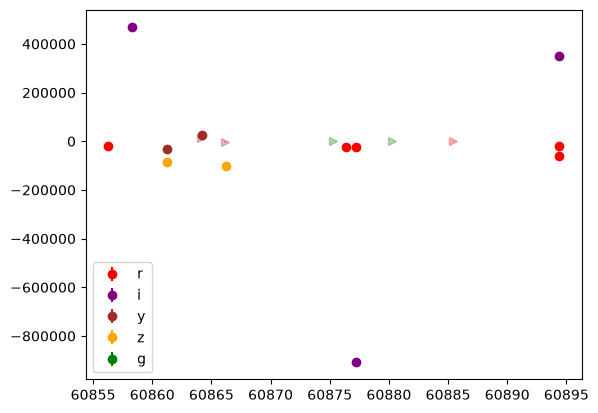

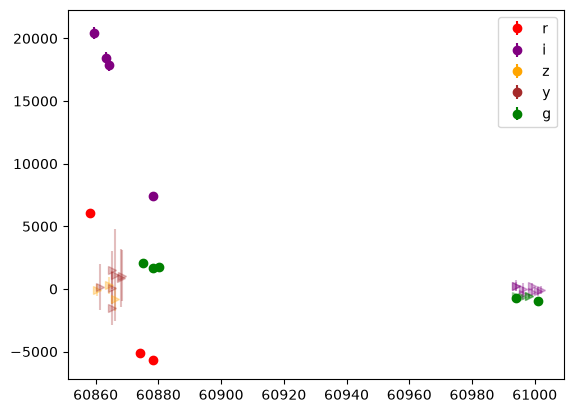

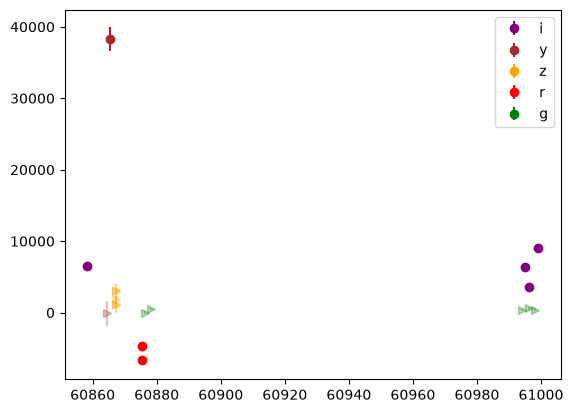

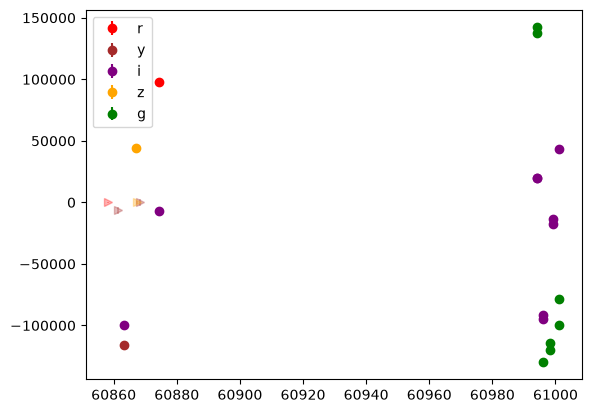

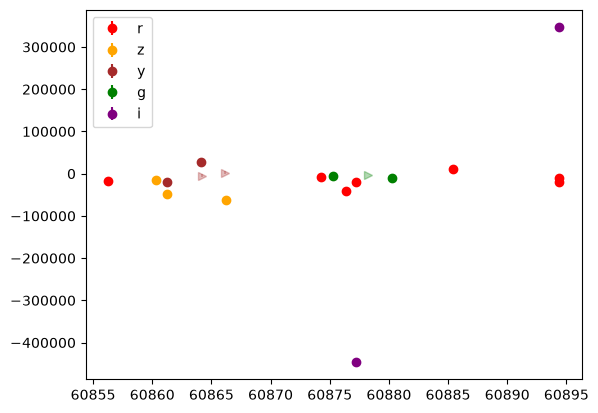

In [24]:
sn = head
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    # plt.subplot(2,1,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc)
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc)
    plt.show()

In [25]:
def lc_quality_cuts(flux,mjd,filter,snr, n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    det = snr > 5
    flux = flux[det]
    mjd = mjd[det]
    filter = filter[det]
    if len(flux) == 0:
        return False
    peak_idx = np.argmax(flux)
    phases = np.floor((mjd - mjd[peak_idx]))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -40) & (unique_phases<=100)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    flux_new = flux[unique_idx][good_idx]
    peak_idx_new = np.argmax(flux_new)
    pass_cut &= (peak_idx_new >= n_before_peak - 1) & (len(flux_new) - peak_idx_new >= n_after_peak - 1)
    good_phases = (phases >= -40) & (phases<=100)
    pass_cut &= len(np.unique(filter[good_phases])) >= n_bands
    return pass_cut

In [26]:
def make_lc_quality_cuts(df):
    df["diaObjectForcedSource_dia_object_lc.snr"] = df["diaObjectForcedSource_dia_object_lc.psfDiffFlux"]/df["diaObjectForcedSource_dia_object_lc.psfDiffFluxErr"]
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=bool) for name in ["pass_quality_cut"]}) 
    else:
        df = df.map_rows(lc_quality_cuts,columns=["diaObjectForcedSource_dia_object_lc.psfDiffFlux",
                                       "diaObjectForcedSource_dia_object_lc.midpointMjdTai",
                                       "diaObjectForcedSource_dia_object_lc.band",
                                       "diaObjectForcedSource_dia_object_lc.snr"],
                                       row_container="args",output_names=["pass_quality_cut"], 
                                       append_columns=True)
    return df

In [27]:
sn_good_after_quality_cut = sn_good.map_partitions(make_lc_quality_cuts)

In [28]:
good_qc_filename = "good_sne_after_quality_cut"

In [29]:
sn_good_after_quality_cut = sn_good_after_quality_cut.query("pass_quality_cut == True")

In [30]:
sn_good_after_quality_cut.head()

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 14.00it/s]


diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1200208372090499939         767473890875146242        345.925452   
1200465576647293282         764256994730180612        339.905651   
1200785904850779412         764256651132796951         338.91889   
1200845017146712741         764257819363901496        339.498045   
1200883739342177866         764259880948203526        339.559885   

                     dec_dia_object_lc  refExtendedness_object_lc  \
_healpix_29                                                         
1200208372090499939          -17.06852                        1.0   
1200465576647293282         -20.147871                        1.0   
1200785904850779412         -20.340729                        1.0   
1200845017146712741         -19.977717                        1.0   
1200883739342177866         -19.467459                        1.0   

                     refSizeExtendedness_object_lc  objectId_object_lc  \
_healpix_29                                                              
1200208372090499939                            1.0  767473890875164932   
1200465576647293282                            1.0  764256994730200287   
1200785904850779412                            1.0  764256651132816445   
1200845017146712741                            1.0  764257819363921111   
1200883739342177866                            1.0  764259880948226844   

                     coord_ra_object_lc  coord_dec_object_lc  _dist_arcsec  \
_healpix_29                                                                  
1200208372090499939          345.924325           -17.069157      4.503291   
1200465576647293282          339.905542           -20.148758      3.212641   
1200785904850779412          338.919773           -20.341296      3.612958   
1200845017146712741          339.497775           -19.977911      1.148908   
1200883739342177866          339.558508           -19.467094      4.851968   

                     ndet  ...  bazin_fit_rise_time_z  bazin_fit_fall_time_z  \
_healpix_29                ...                                                 
1200208372090499939    11  ...                   <NA>                   <NA>   
1200465576647293282    13  ...                   <NA>                   <NA>   
1200785904850779412    19  ...                   <NA>                   <NA>   
1200845017146712741    10  ...                   <NA>                   <NA>   
1200883739342177866    10  ...                   <NA>                   <NA>   

                     bazin_fit_reduced_chi2_z       chi2_g       chi2_r  \
_healpix_29                                                               
1200208372090499939                      <NA>    85.597572   826.755066   
1200465576647293282                      <NA>   489.055481  1158.308228   
1200785904850779412                      <NA>  1010.743896  9849.060547   
1200845017146712741                      <NA>    42.402779   386.735474   
1200883739342177866                      <NA>    35.670322    51.351063   

                           chi2_i       chi2_z  \
_healpix_29                                      
1200208372090499939     380.85672     0.433459   
1200465576647293282      4.225089    28.198563   
1200785904850779412   6163.311523  5146.881348   
1200845017146712741     228365.25    43.431427   
1200883739342177866  310356.28125    18.690752   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
1200208372090499939  [{midpointMjdTai: 60858.284129, band: 'r', psf...   
1200465576647293282  [{midpointMjdTai: 60856.281898, band: 'r', psf...   
1200785904850779412  [{midpointMjdTai: 60856.281898, band: 'r', psf...   
1200845017146712741  [{midpointMjdTai: 60856.281898, band: 'r', psf...   
1200883739342177866  [{midpointMjdTai: 60856.281898, band: 'r', psf...   

                                     

In [31]:
sn_good_after_quality_cut.write_catalog(outdir / good_qc_filename,overwrite=True)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.22 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
Writing Catalog: 100%|██████████| 8534/8534 [01:12<00:00, 118.49it/s]


In [32]:
sn_good_after_quality_cut = lsdb.open_catalog(outdir / good_qc_filename)
len(sn_good_after_quality_cut)

38215

In [33]:
head = sn_good_after_quality_cut.head()

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 27.21it/s]


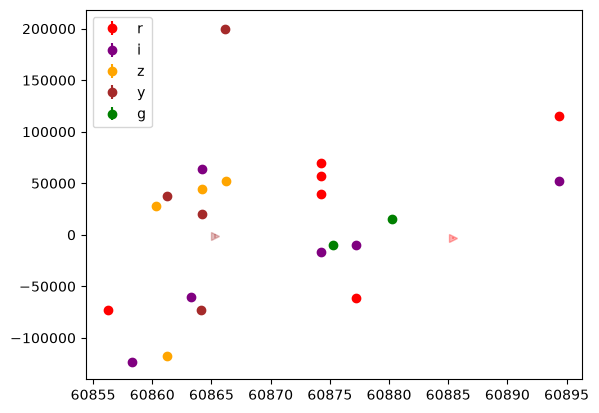

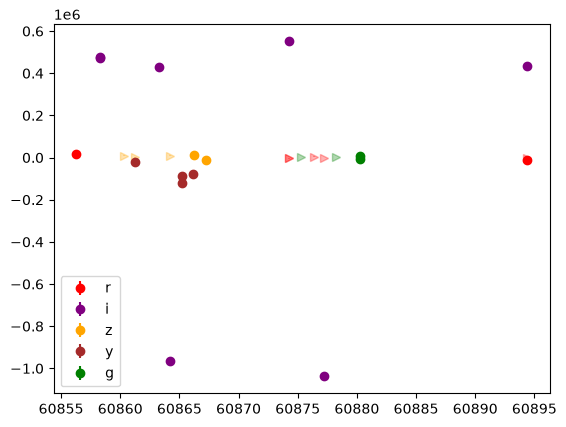

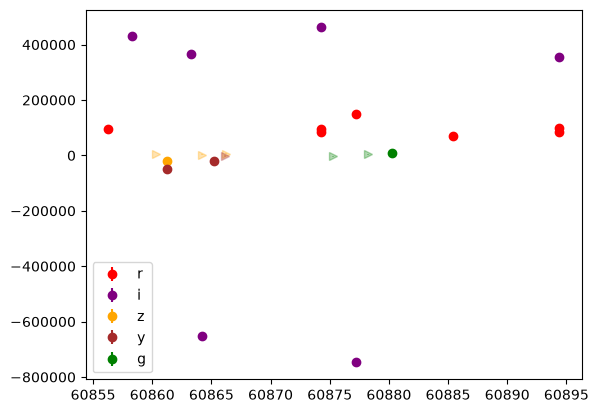

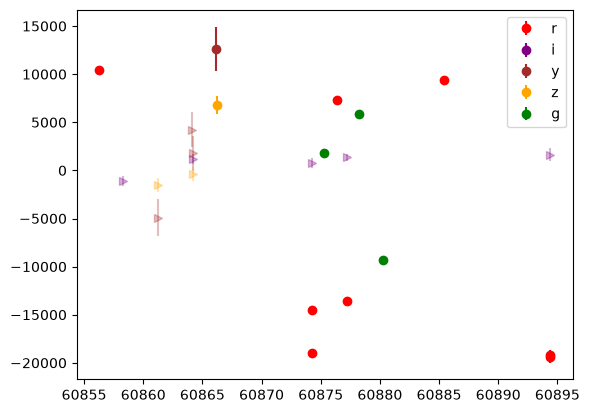

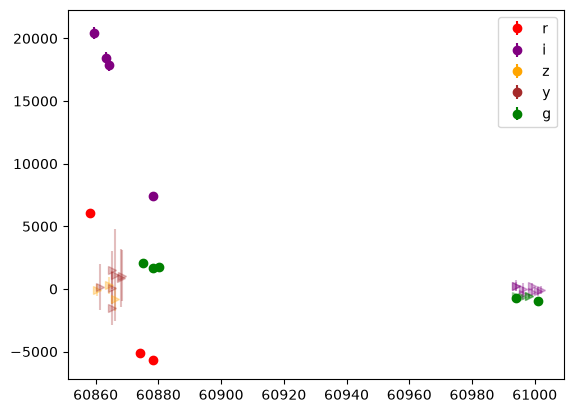

In [34]:
sn = head
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    # plt.subplot(2,1,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc)
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc)
    plt.show()

### Retry rejected difference-flux fits with per-band reference levels

The photometry is signed difference flux. With `RETRY_BAND_BASELINES=True`, a failed or rejected SALT fit is retried with $F_{\rm diff,b}(t)=F_{\rm SALT,b}(t)+B_b$, where each $B_b$ is a free constant in nJy. The retry uses surviving DiaSource rows with finite flux and positive finite errors, retaining their negative fluxes. Forced photometry is used for the existing phase checks, not for this SALT fit. Passing original fits are retained.

The retry fits redshift and the SALT parameters jointly with the reference levels. It must pass the existing SALT/chi-square cuts, have positive degrees of freedom and a nonsingular covariance, a positive amplitude detected above five formal sigma, and an interior redshift. A same-row comparison must improve BIC after counting the extra reference parameters. The initial and final forced-photometry phase checks keep their existing positive-SNR detection requirement. This retry therefore only recovers candidates that already reach the SALT stage and still pass the final phase check.

Three redshift seeds use the peak-flux estimate, half that estimate, and the original fitted value. Each uses the existing sncosmo phase-window iteration; the final phase subset is refitted with fixed rows. Among acceptable retries, the solution with the most retained epochs is preferred, then the smallest reduced chi-square.

`legacy_*` columns retain the original fit summary, `baseline_*` records fitted levels and their marginal errors, and `baseline_recovered` identifies the added candidates. The exported SALT covariance is marginalized over the fitted reference levels; their individual marginal errors are saved, but the full joint covariance with the reference levels is not exported. A fitted reference level does not establish a template-contamination mechanism. The intermediate filenames identify the reference-fit run; the final sample includes accepted original and recovered candidates, and a separate recovered-candidate Parquet is also written. Downstream saved outputs have been cleared pending a survey rerun.

In [ ]:
from lcfit import fit_single_lc, saltres_cols
from sncosmo.fitting import flatten_result


class BandReferenceLevels(sncosmo.PropagationEffect):
    """Parameter container; additive levels are applied in bandflux, not the SED."""
    _minwave = 0.0
    _maxwave = np.inf

    def __init__(self, filters):
        self._param_names = list(filters)
        self.param_names_latex = list(filters)
        self._parameters = np.zeros(len(filters))

    def propagate(self, wave, flux, phase=None):
        return flux


class DifferenceSALTModel(sncosmo.Model):
    """SALT3 + one signed constant per observer band, expressed in nJy.

    For photometric fits with modelcov=False only. Reference levels are
    nuisance parameters, not measured template fluxes or an SED component.
    """
    def __init__(self, filters, source="salt3"):
        self.reference_filters = tuple(filters)
        super().__init__(source=source,
                         effects=[sncosmo.F99Dust(), BandReferenceLevels(filters)],
                         effect_names=["mw", "ref"], effect_frames=["obs", "obs"])

    def __copy__(self):
        copied = type(self)(self.reference_filters, source=self.source)
        copied.parameters = self.parameters.copy()
        return copied

    def bandflux(self, band, time, zp=None, zpsys=None):
        flux = np.asarray(super().bandflux(band, time, zp=zp, zpsys=zpsys))
        bands = np.broadcast_to(np.asarray(band), flux.shape)
        offset = np.zeros_like(flux)
        if zp is not None:
            zps = np.broadcast_to(np.asarray(zp), flux.shape)
            systems = np.broadcast_to(np.asarray(zpsys), flux.shape)
        for item in set(bands.flat):
            bp = sncosmo.get_bandpass(item)
            filt = bp.name.removeprefix("lynx_lsst_")
            if filt not in self.reference_filters:
                raise ValueError(f"No reference parameter for band {bp.name}")
            mask = bands == item
            # Convert nJy (AB zp=31.4) to photons, then to the requested units.
            photons = self.get("ref" + filt) * 10**(-0.4 * 31.4)
            photons *= sncosmo.get_magsystem("ab").zpbandflux(bp)
            if zp is None:
                offset[mask] = photons
            else:
                for system in set(systems[mask].flat):
                    selected = mask & (systems == system)
                    offset[selected] = (photons * 10**(0.4 * zps[selected]) /
                                        sncosmo.get_magsystem(system).zpbandflux(bp))
        result = flux + offset
        return result.item() if result.ndim == 0 else result

    def bandfluxcov(self, *args, **kwargs):
        raise ValueError("Reference-level retry currently requires modelcov=False")


legacy_fields = ["success", "chisq", "ndof", "z", "t0", "x0", "x1", "c"]
baseline_numeric = (["legacy_" + key for key in legacy_fields] +
                    ["baseline_recovered", "baseline_nband", "baseline_delta_bic"] +
                    ["baseline_" + band + suffix for band in "ugrizy"
                     for suffix in ["", "_err"]])
baseline_text = ["fit_model", "baseline_status"]
salt_output_columns = saltres_cols + baseline_numeric + baseline_text
salt_output_dtypes = ([np.float64] * (len(saltres_cols) - 2) + [int, str] +
                      [np.float64] * len(baseline_numeric) + [str] * len(baseline_text))


def normalize_salt_output(result):
    """Use identical scalar types in legacy/recovered/empty HATS partitions."""
    return {name: dtype(result[name])
            for name, dtype in zip(salt_output_columns, salt_output_dtypes)}


def passes_salt_cuts(result):
    return (result["success"] == 1 and -3.99 < result["x1"] < 3.99 and
            -0.399 < result["c"] < 0.799 and result["mwebv"] < 0.25 and
            result["ndof"] > 0 and 0 < result["chisq"] / result["ndof"] < 20)


def fit_single_lc_w_cond(lc, bounds=None, phase_range=(-15, 45), modelcov=False):
    """Keep passing zero-baseline fits; retry rejected fits with signed band levels."""
    bounds = {"x1": (-4, 4), "c": (-0.4, 0.8)} if bounds is None else bounds.copy()
    legacy = fit_single_lc(lc.copy(), mpbounds=bounds.copy(),
                           phase_range=phase_range, modelcov=modelcov)
    output = dict(legacy)
    output.update({name: np.nan for name in baseline_numeric})
    output.update({"legacy_" + key: legacy[key] for key in legacy_fields})
    output.update(baseline_recovered=0.0, fit_model="salt3", baseline_status="not_needed")
    for band in "ugrizy":
        output["baseline_" + band] = 0.0
    if not RETRY_BAND_BASELINES or passes_salt_cuts(legacy):
        return normalize_salt_output(output)
    if modelcov:
        raise ValueError("Band-baseline retry is only implemented for modelcov=False")
    output["baseline_status"] = "no_acceptable_reference_fit"

    try:
        from astropy.table import Table
        from sfdmap2 import sfdmap
        time = np.asarray(lc["diaSource_dia_object_lc.midpointMjdTai"], dtype=float)
        flux = np.asarray(lc["diaSource_dia_object_lc.psfFlux"], dtype=float)
        error = np.asarray(lc["diaSource_dia_object_lc.psfFluxErr"], dtype=float)
        filters = np.asarray(lc["diaSource_dia_object_lc.band"], dtype=str)
        valid = np.isfinite(time + flux + error) & (error > 0)
        data = Table({"time": time[valid], "flux": flux[valid], "fluxerr": error[valid],
                      "band": np.char.add("lynx_lsst_", filters[valid]),
                      "zp": np.full(valid.sum(), 31.4), "zpsys": np.full(valid.sum(), "ab")})
        zest = float(lc["z_est"])
        zerr = float(lc.get("z_est_err", 0.15))
        zlo, zhi = max(0.0, zest - 3*zerr), zest + 3*zerr
        fitbounds = dict(bounds, z=(zlo, zhi))
        dust = float(sfdmap.SFDMap().ebv(lc["ra_dia_object_lc"], lc["dec_dia_object_lc"]))
        if not np.isfinite(dust) or dust >= 0.25:
            return normalize_salt_output(output)
        base = sncosmo.Model(source="salt3", effects=[sncosmo.F99Dust()],
                             effect_names=["mw"], effect_frames=["obs"])
        base.set(mwebv=dust)
        # Use the same full-bandpass support rule as sncosmo.fit_lc throughout z bounds.
        support = np.all(base.bandoverlap(data["band"], z=[zlo, zhi]), axis=1)
        data = data[support]
        used = sorted({str(b).removeprefix("lynx_lsst_") for b in data["band"]})
        if len(used) < 3 or len(data) <= 5 + len(used):
            output["baseline_status"] = "insufficient_reference_fit_support"
            return normalize_salt_output(output)
        # A flux range is invariant to an additive reference level; use it only for seeds.
        seed_band = max(used, key=lambda b: np.ptp(data["flux"][data["band"] == "lynx_lsst_"+b]) /
                        np.median(data["fluxerr"][data["band"] == "lynx_lsst_"+b]))
        seed_rows = data[data["band"] == "lynx_lsst_"+seed_band]
        zstarts = [zest, max(zlo + 1e-4, zest / 2), legacy.get("z", np.nan)]
        candidates = []
        for zstart in dict.fromkeys(zstarts):
            if not np.isfinite(zstart) or not zlo < zstart < zhi:
                continue
            try:
                model = DifferenceSALTModel(used)
                model.set(z=zstart, mwebv=dust, x0=1.0, x1=0.0, c=0.0, t0=0.0)
                grid = np.linspace(-15, 40, 111) * (1 + zstart)
                curve = model.bandflux("lynx_lsst_"+seed_band, grid, zp=31.4, zpsys="ab")
                t0 = float(seed_rows["time"][np.argmax(seed_rows["flux"])]) - grid[np.argmax(curve)]
                amplitude = max(np.ptp(seed_rows["flux"]) / np.max(curve), 1e-12)
                model.set(t0=t0, x0=amplitude)
                for band in used:
                    rows = data[data["band"] == "lynx_lsst_"+band]
                    prediction = model.bandflux(rows["band"], rows["time"], zp=31.4, zpsys="ab")
                    model.set(**{"ref"+band: float(np.median(rows["flux"] - prediction))})
                pars = ["z", "t0", "x0", "x1", "c"] + ["ref"+b for b in used]
                result, fitted = sncosmo.fit_lc(
                    data, model, pars, bounds=fitbounds, modelcov=False,
                    guess_z=False, guess_t0=False, guess_amplitude=False,
                    phase_range=phase_range, maxcall=3000, warn=False)
                # Refit the converged phase subset on fixed rows; drop unconstrained
                # reference parameters for bands that have no rows in this subset.
                selected = data[result.data_mask]
                active = sorted({str(b).removeprefix("lynx_lsst_") for b in selected["band"]})
                if len(active) < 3 or len(selected) <= 5 + len(active):
                    continue
                pars = ["z", "t0", "x0", "x1", "c"] + ["ref"+b for b in active]
                result, fitted = sncosmo.fit_lc(
                    selected, fitted, pars, bounds=fitbounds, modelcov=False,
                    guess_z=False, guess_t0=False, guess_amplitude=False,
                    maxcall=3000, warn=False)
                flat = flatten_result(result)
                phases = (selected["time"] - flat["t0"]) / (1 + flat["z"])
                if (not passes_salt_cuts(flat) or np.any(phases < phase_range[0]) or
                        np.any(phases > phase_range[1]) or result.covariance is None):
                    continue
                cov = result.covariance
                sigma = np.sqrt(np.diag(cov))
                corr = cov / np.outer(sigma, sigma)
                if (not np.all(np.isfinite(corr)) or np.min(np.linalg.eigvalsh(corr)) <= 1e-10 or
                        flat["x0"] <= 5 * flat["x0_err"] or
                        min(flat["z"]-zlo, zhi-flat["z"]) <= 1e-4):
                    continue
                # Compare both models on exactly these same rows, including negative fluxes.
                base.set(**{key: flat[key] for key in ["z", "t0", "x0", "x1", "c", "mwebv"]})
                zero, _ = sncosmo.fit_lc(
                    selected, base, ["z", "t0", "x0", "x1", "c"], bounds=fitbounds,
                    modelcov=False, guess_z=False, guess_t0=False, guess_amplitude=False,
                    maxcall=3000, warn=False)
                delta_bic = zero.chisq - result.chisq - len(active)*np.log(len(selected))
                if not zero.success or not np.isfinite(delta_bic) or delta_bic <= 0:
                    continue
                candidates.append((len(selected), -result.chisq/result.ndof,
                                   flat, active, delta_bic))
            except (ValueError, RuntimeError, FloatingPointError):
                continue
        if candidates:
            # Prefer solutions supported by more epochs, then smaller reduced chi-square.
            _, _, fitted, active, delta_bic = max(candidates, key=lambda item: item[:2])
            output.update({key: fitted[key] for key in saltres_cols if key not in ["id", "fit_error"]})
            output.update(fit_error="None", baseline_recovered=1.0,
                          fit_model="salt3_plus_band_reference", baseline_status="accepted",
                          baseline_nband=float(len(active)), baseline_delta_bic=float(delta_bic))
            for band in active:
                output["baseline_"+band] = fitted["ref"+band]
                output["baseline_"+band+"_err"] = fitted["ref"+band+"_err"]
    except (ValueError, RuntimeError, FloatingPointError) as exc:
        output["baseline_status"] = "reference_fit_error: " + str(exc)
    return normalize_salt_output(output)

In [ ]:
def infer_z_from_peakmag(row):
    peakflux = np.max(row)
    peakmag = flux2mag(peakflux)
    z = Distance(distmod = peakmag + 19).compute_z(cosmology=Planck18).value
    return z

In [ ]:
def compute_z_from_peakmag(df):
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=np.float32) for name in ["z_est"]}) 
    else:
        df = df.map_rows(infer_z_from_peakmag, columns=["diaSource_dia_object_lc.psfFlux"], row_container="args",
                         output_names=["z_est"], append_columns=True)
    return df

In [ ]:
def fit_salt2(df):
    if len(df) == 0:
        return df.assign(**{name: np.array([], dtype=dtype)
                            for name, dtype in zip(salt_output_columns, salt_output_dtypes)})
    return df.map_rows(
        fit_single_lc_w_cond,
        columns=["ra_dia_object_lc", "dec_dia_object_lc", "diaObjectId_dia_object_lc", "z_est",
                 "diaSource_dia_object_lc.midpointMjdTai", "diaSource_dia_object_lc.band",
                 "diaSource_dia_object_lc.psfFlux", "diaSource_dia_object_lc.psfFluxErr"],
        append_columns=True)

In [ ]:
sn_good_after_quality_cut = lsdb.open_catalog(outdir / good_qc_filename)
sn_good_after_quality_cut = sn_good_after_quality_cut.map_partitions(compute_z_from_peakmag)

In [ ]:
# # for debugging
# sn_good_after_quality_cut = sn_good_after_quality_cut.partitions[0:100]

In [ ]:
res = sn_good_after_quality_cut.map_partitions(fit_salt2,compute_single_partition=False)

In [ ]:
head = res.head()

In [ ]:
head

In [ ]:
fit_suffix = ("_band_reference" + ("_ddf" if DDF else "")) if RETRY_BAND_BASELINES else ""
saltres_file = "saltfit_on_good_sne_after_quality_cut" + fit_suffix

In [ ]:
if refit_salt:
    res.write_catalog(outdir / saltres_file,overwrite=True)

In [ ]:
columns = ['diaObjectId_dia_object_lc','success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err', 'x0',
           'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err', 'z_z_cov',
           'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
           't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
           't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
           'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
           'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
           'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
           'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
           'mwebv_mwebv_cov', 'id', 'fit_error', 'diaSource_dia_object_lc',
           'diaObjectForcedSource_dia_object_lc','_dist_arcsec']
# saltres = lsdb.open_catalog(outdir / saltres_file, columns=columns+bazin_cols)
saltres = lsdb.open_catalog(outdir / saltres_file, columns="all")
len(saltres)

In [ ]:
saltres.columns

In [ ]:
saltres = saltres.query("success == 1 and "
                        "(x1 > -3.99 and x1 < 3.99) and " 
                        "(c > -0.399 and c < 0.799) and "
                        "mwebv < 0.25")

In [ ]:
saltres_after_cut = "saltfit_on_good_sne_after_quality_cut_and_saltpar_cut" + fit_suffix

In [ ]:
saltres.write_catalog(outdir / saltres_after_cut,overwrite=True)

In [ ]:
saltres = lsdb.open_catalog(outdir / saltres_after_cut, columns="all")

In [ ]:
saltres.plot_pixels()

In [ ]:
result_good = saltres.compute()

In [ ]:
sample_suffix = ("_ddf" if DDF else "") + ("_band_reference" if RETRY_BAND_BASELINES else "")
res_filename = "saltfit_good_sne" + sample_suffix + ".parquet"

In [ ]:
result_good.to_parquet(outdir / res_filename)

In [ ]:
result_good = npd.read_parquet(outdir / res_filename)
# Old saved fits can still be read when the reference retry is disabled.
if "baseline_recovered" not in result_good.columns:
    if RETRY_BAND_BASELINES:
        raise ValueError("This catalog has no band-reference fits; run with refit_salt=True first.")
    result_good["baseline_recovered"] = 0.0
    for band in "ugrizy":
        result_good["baseline_" + band] = 0.0

In [ ]:
result_good

In [ ]:
plt.subplot(1,2,1)
result_good.x1.hist()
plt.subplot(1,2,2)
result_good.c.hist()

In [ ]:
result_good["reduced_chisq"] = result_good.chisq / result_good.ndof

In [ ]:
result_good.reduced_chisq.hist(bins = np.linspace(0, 100, 20))

In [ ]:
sn_good = result_good.loc[(result_good.reduced_chisq > 0.) & (result_good.reduced_chisq < 20.)]

In [ ]:
sn_good

In [ ]:
plt.subplot(1,2,1)
sn_good.x1.hist()
plt.subplot(1,2,2)
sn_good.c.hist()

In [ ]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux,mjd,filter,z,t0,n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[(phases >=-10) & (phases <=40)])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [ ]:
sn = sn_good

In [ ]:
sn["diaObjectForcedSource_dia_object_lc.snr"] = sn["diaObjectForcedSource_dia_object_lc.psfDiffFlux"]/sn["diaObjectForcedSource_dia_object_lc.psfDiffFluxErr"]
sn_det = sn.query("diaObjectForcedSource_dia_object_lc.snr > 5")
pass_quality_cut = sn_det.map_rows(lc_quality_cuts,columns=["diaObjectForcedSource_dia_object_lc.psfDiffFlux",
                               "diaObjectForcedSource_dia_object_lc.midpointMjdTai",
                               "diaObjectForcedSource_dia_object_lc.band","z","t0"],
                               row_container="args")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
sn["pass_quality_cuts"] = False
sn.loc[idx,"pass_quality_cuts"] = True
sn = sn[sn["pass_quality_cuts"] == True]

In [ ]:
sn

In [ ]:
from legacy_survey_cutout import plot_legacy_cutout
cols = ["x0","x1","c","z","mwebv","t0"]
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    saltpars_df = result_good.loc[result_good.id==sn.iloc[i]["diaObjectId_dia_object_lc"]]
    saltpars = {}
    for col in cols:
        saltpars[col] = saltpars_df[col].values[0]
    print(saltpars)
    print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))
    plt.figure(figsize=(12,4))
    ax = plt.subplot(1,3,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    phase = (lc["midpointMjdTai"] - saltpars["t0"])/(1.+saltpars["z"])
    good_phase = (phase > -30) & (phase < 100)
    lc = lc.loc[good_phase]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    # lc_coadd = nightly_coadd(lc["mjd"],lc["band"],lc["flux"],lc["fluxerr"])
    # lc_coadd["snr"] = lc_coadd["flux"]/lc_coadd["fluxerr"]
    # plot_lc(lc_coadd,saltpars=saltpars)
    baseline_offsets = {band: saltpars_df["baseline_" + band].iloc[0] for band in "ugrizy"}
    plot_lc(lc, saltpars=saltpars, baseline_offsets=baseline_offsets)
    plt.title(f"diaObjectId={sn.iloc[i]['diaObjectId_dia_object_lc']}")
    # plt.subplot(1,3,1)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc,saltpars=saltpars)
    ax2 = plt.subplot(1,3,2)
    plt.plot(sn.iloc[i]["diaSource_dia_object_lc"]["midpointMjdTai"],sn.iloc[i]["diaSource_dia_object_lc"]["reliability"],'o')
    plt.xlim(ax.get_xlim())
    # ax = plt.subplot(1,3,3)
    # ra = sn.iloc[i]["ra_dia_object_lc"]
    # dec = sn.iloc[i]["dec_dia_object_lc"]
    # img = plot_legacy_cutout(ra, dec, size=115, pixscale=0.262, layer="ls-dr10", fmt="jpg",ax=ax)
    plt.show()

In [ ]:
final_name = "final_sample_ddf.parquet" if DDF else "final_sample.parquet"
sn.to_parquet(outdir / final_name)
recovered = sn.loc[sn["baseline_recovered"] == 1]
recovered.to_parquet(outdir / ("recovered_band_reference" + ("_ddf" if DDF else "") + ".parquet"))
print(f"Final candidates: {len(sn)}; recovered by band reference fits: {len(recovered)}")